In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn.preprocessing as skl_pre
import sklearn.linear_model as skl_lm
import sklearn.discriminant_analysis as skl_da
import sklearn.neighbors as skl_nb
import sklearn.model_selection as skl_ms

data = pd.read_csv('training_data_VT2026.csv', dtype={'ID': str}).reset_index(drop=True)

data.info()




X = data.iloc[:, :-1]
y =data.iloc[:, -1]




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hour_of_day     1600 non-null   int64  
 1   day_of_week     1600 non-null   int64  
 2   month           1600 non-null   int64  
 3   holiday         1600 non-null   int64  
 4   weekday         1600 non-null   int64  
 5   summertime      1600 non-null   int64  
 6   temp            1600 non-null   float64
 7   dew             1600 non-null   float64
 8   humidity        1600 non-null   float64
 9   precip          1600 non-null   float64
 10  snow            1600 non-null   int64  
 11  snowdepth       1600 non-null   float64
 12  windspeed       1600 non-null   float64
 13  cloudcover      1600 non-null   float64
 14  visibility      1600 non-null   float64
 15  increase_stock  1600 non-null   object 
dtypes: float64(8), int64(7), object(1)
memory usage: 200.1+ KB


In [2]:
'''
 0   hour_of_day     categorical 
 1   day_of_week     categorical
 2   month           categorical
 3   holiday         categorical
 4   weekday         categorical 
 5   summertime      categorical
 6   temp            numerical
 7   dew             numerical
 8   humidity        numerical
 9   precip          numerical
 10  snow            categorical
 11  snowdepth       numerical
 12  windspeed       numerical
 13  cloudcover      numerical
 14  visibility      numerical
 15  increase_stock  object
'''

X_num = X[['temp', 'dew','humidity','precip','snowdepth','windspeed','cloudcover','visibility']]
data.head()

,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility,increase_stock
0,5,5,1,0,0,0,-7.2,-15.0,53.68,0.0,0,0.0,16.3,31.6,16.0,low_bike_demand
1,21,4,1,0,1,0,-1.3,-12.8,40.97,0.0,0,0.0,23.9,85.7,16.0,low_bike_demand
2,21,3,8,0,1,1,26.9,21.8,73.39,0.0,0,0.0,0.0,81.1,16.0,low_bike_demand
3,1,6,1,0,0,0,3.1,-4.0,59.74,0.0,0,0.0,19.2,0.0,16.0,low_bike_demand
4,17,0,3,0,1,0,11.7,-11.4,18.71,0.0,0,0.0,10.5,44.6,16.0,low_bike_demand


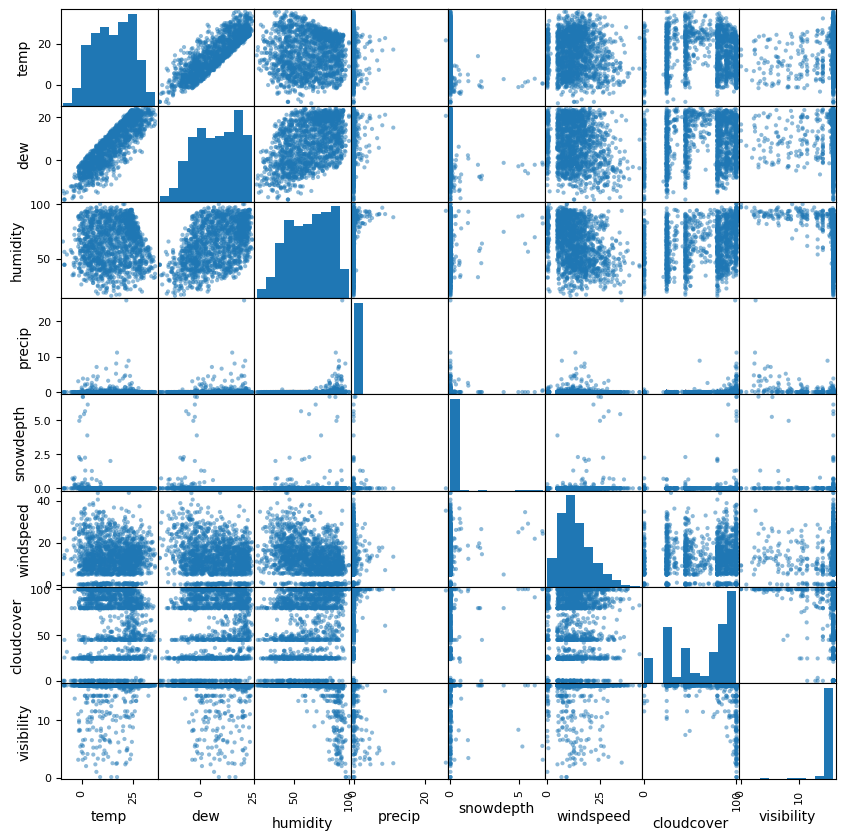

In [3]:
pd.plotting.scatter_matrix(X_num, figsize=(10,10))
plt.show()

In [4]:
variances = {}
for k in X_num.columns:
    variances[k] = X_num[k].var()

print(variances)

data["increase_stock"] = data["increase_stock"].map({
    "low_bike_demand": 0,
    "high_bike_demand": 1
})

mean_time = data.loc[data["increase_stock"] == 1, "hour_of_day"].mean()
std_time  = data.loc[data["increase_stock"] == 1, "hour_of_day"].std()

data["rush_hour"] = ((data["hour_of_day"] >= (mean_time-(1.5*std_time))) & (data["hour_of_day"] <= (mean_time+(1.5*std_time)))).astype(int)

data.head()



{'temp': 85.83623504924945, 'dew': 100.52988061288298, 'humidity': 364.02424319008037, 'precip': 0.8475037724793102, 'snowdepth': 0.17740739696684904, 'windspeed': 60.16564727954977, 'cloudcover': 1072.4884421357083, 'visibility': 5.399752829893848}


,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility,increase_stock,rush_hour
0,5,5,1,0,0,0,-7.2,-15.0,53.68,0.0,0,0.0,16.3,31.6,16.0,0,0
1,21,4,1,0,1,0,-1.3,-12.8,40.97,0.0,0,0.0,23.9,85.7,16.0,0,0
2,21,3,8,0,1,1,26.9,21.8,73.39,0.0,0,0.0,0.0,81.1,16.0,0,0
3,1,6,1,0,0,0,3.1,-4.0,59.74,0.0,0,0.0,19.2,0.0,16.0,0,0
4,17,0,3,0,1,0,11.7,-11.4,18.71,0.0,0,0.0,10.5,44.6,16.0,0,1


In [5]:
# logistic regression module to see importance from all features
features = [
    'hour_of_day','day_of_week','month','holiday','weekday','summertime',
    'temp','dew','humidity','precip','snow','snowdepth',
    'windspeed','cloudcover','visibility','rush_hour'
]


corr = (
    data[features + ["increase_stock"]]
    .corr()
    ["increase_stock"]
    .drop("increase_stock")
    .sort_values(key=abs, ascending=False)
)

print(corr)


rush_hour      0.466325
temp           0.336981
humidity      -0.308726
hour_of_day    0.240544
summertime     0.216052
dew            0.132663
weekday       -0.116446
visibility     0.113443
windspeed      0.096011
day_of_week    0.083688
precip        -0.059304
snowdepth     -0.047526
cloudcover    -0.045534
month          0.037212
holiday       -0.004909
snow                NaN
Name: increase_stock, dtype: float64


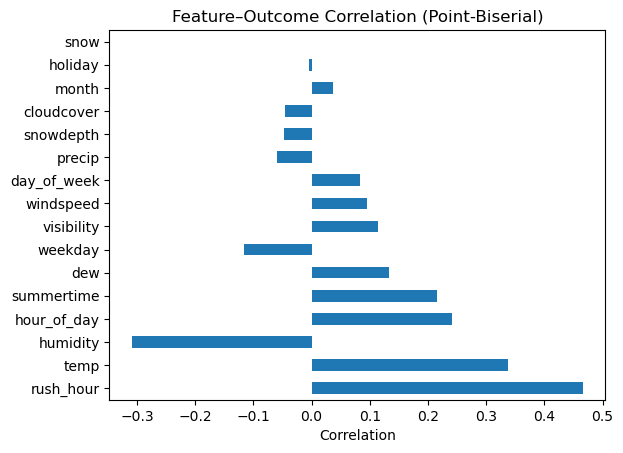

In [6]:
corr.plot(kind="barh")
plt.title("Feature–Outcome Correlation (Point-Biserial)")
plt.xlabel("Correlation")
plt.show()

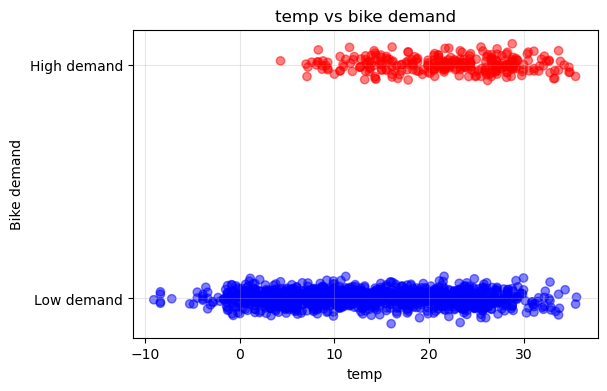

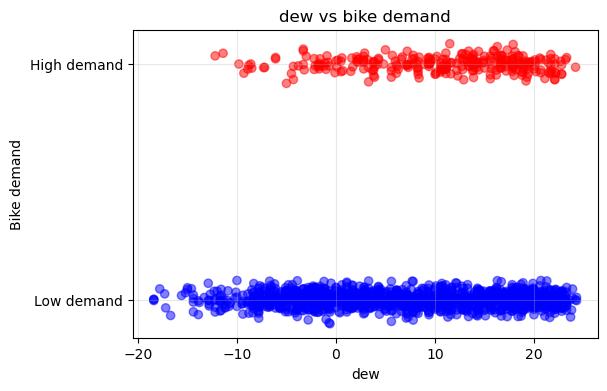

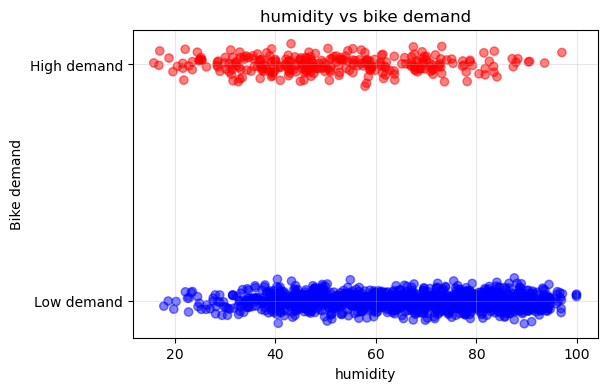

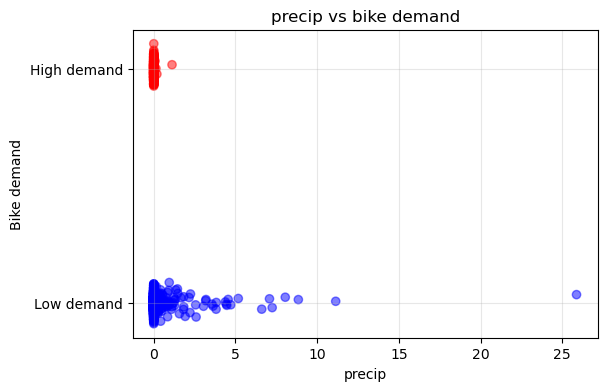

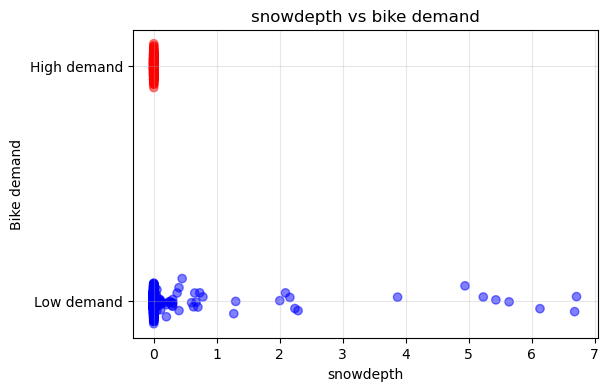

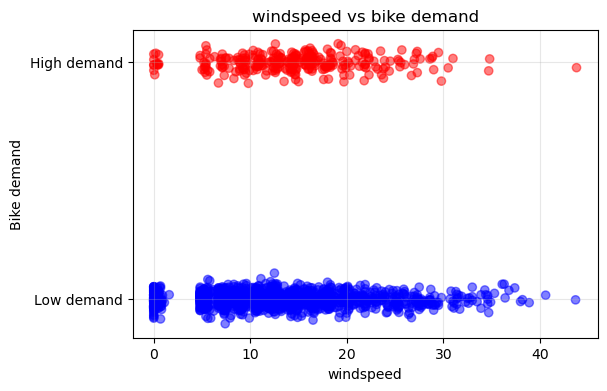

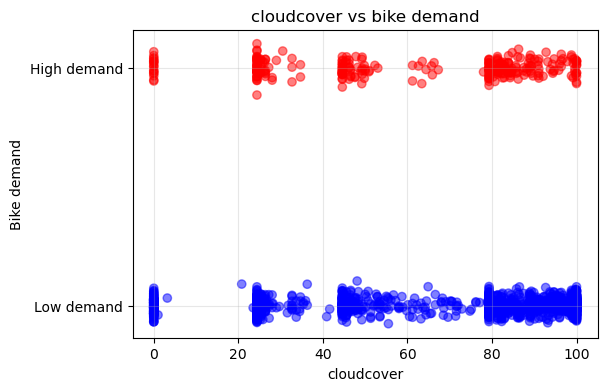

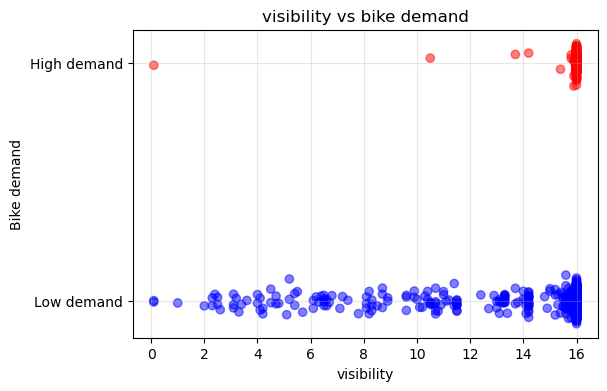

In [ ]:
#1D Scatter plots for numerical features

numerical_features = ['temp', 'dew', 'humidity', 'precip', 'snowdepth', 'windspeed', 'cloudcover', 'visibility']

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    
    # jitter för bättre synlighet
    y_jitter = data["increase_stock"] + np.random.normal(0, 0.03, size=len(data))
    
    plt.scatter(
        data[col],
        y_jitter,
        c=data["increase_stock"],
        cmap="bwr",
        alpha=0.5
    )
    
    plt.yticks([0, 1], ["Low demand", "High demand"])
    plt.xlabel(col)
    plt.ylabel("Bike demand")
    plt.title(f"{col} vs bike demand")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# Scatter plots for categorical features

In [8]:
holiday1 = (
    data.loc[data["holiday"] == 1, "increase_stock"]
    .mean()
)




rush_hour1 = (
    data.loc[data["rush_hour"] == 1, "increase_stock"]
    .mean()
)

print(rush_hour1)

0.41098169717138106


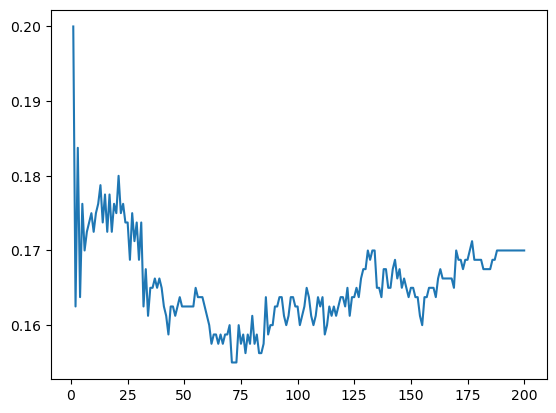

In [9]:
#KNN

k_array = np.arange(1,201)
scores = []

good_features = ['rush_hour', 'temp', 'humidity','summertime','visibility']

X = data[good_features]
y = data['increase_stock']

N = len(X)

M = N//2
index = np.random.permutation(N)
X_train = np.array(X.iloc[index[:M]])
y_train = np.array(y.iloc[index[:M]])
X_test = np.array(X.iloc[index[M:]])
y_test =  np.array(y.iloc[index[M:]])

for k in k_array:
    model = skl_nb.KNeighborsClassifier(int(k)).fit(X_train,y_train)
    pred = model.predict(X_test)
    scores.append(np.mean(pred != y_test))

plt.plot(k_array,scores)
plt.show()